# Imports

In [18]:
import subprocess
import json
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
)

import sys
sys.path.append('..')
from pipeline import (
    RF_FEATURES, SVM_FEATURES, SVM_SCALE_COLS,
    RF_MINMAX_COLS, RF_STANDARD_COLS,
    filter_port, decode_attack_labels, ATTACK_LABELS,
)

# Label dataset

In [10]:
# label_dataset.py will stamp Attack_type onto traffic_log.csv using
# the timestamps written by run_attack.py.
# Output: traffic_log_labeled.csv
result = subprocess.run(
    ['python', 'label_dataset.py'],
    cwd='../services/attacks/',
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Labeling dataset using attack windows from ../../ryu-controller/run_attack_log.json...
Loaded 7 attack windows from ../../ryu-controller/run_attack_log.json
  SLOWLORIS        start=1776354656.03  end=1776355056.13  duration=400s
  UDP_flood        start=1776355106.14  end=1776355246.25  duration=140s
  ICMP_flood       start=1776358365.35  end=1776358505.45  duration=140s
  SYN_flood        start=1776358555.50  end=1776358695.61  duration=140s
  UDP_flood        start=1776358745.66  end=1776358885.77  duration=140s
  HTTP_flood       start=1776358935.82  end=1776359075.93  duration=140s
  LAND_attack      start=1776359125.99  end=1776359266.10  duration=140s

Processing ../../ryu-controller/traffic_log.csv line-by-line to avoid memory limits...

Labeling results:
  Total rows  : 4107420
  Attack rows : 1527143
  Normal rows : 2580277

Attack type distribution:
SYN_flood       396480
UDP_flood       380310
ICMP_flood      354143
HTTP_flood      323400
LAND_attack     71100
SLOWLORIS   

# Load and Inspect

In [28]:
chunks = []
for chunk in pd.read_csv('../ryu-controller/traffic_log_labeled.csv', chunksize=100000):
    # keep attack traffic only and drop 'Normal' to save memory immediately
    attack_chunk = chunk[chunk['Traffic'] == 'Attack']
    chunks.append(attack_chunk)

df = pd.concat(chunks, ignore_index=True)

print(df['Attack_type'].value_counts())
print(f'Total attack samples: {len(df)}')

C:\Users\moulo\AppData\Local\Temp\ipykernel_16872\1452799792.py:2: DtypeWarning: Columns (0: Attack_type) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('../ryu-controller/traffic_log_labeled.csv', chunksize=100000):
C:\Users\moulo\AppData\Local\Temp\ipykernel_16872\1452799792.py:2: DtypeWarning: Columns (0: Attack_type) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('../ryu-controller/traffic_log_labeled.csv', chunksize=100000):
C:\Users\moulo\AppData\Local\Temp\ipykernel_16872\1452799792.py:2: DtypeWarning: Columns (0: Type_protocole, 1: Attack_type) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('../ryu-controller/traffic_log_labeled.csv', chunksize=100000):
C:\Users\moulo\AppData\Local\Temp\ipykernel_16872\1452799792.py:2: DtypeWarning: Columns (0: Attack_type) have mixed types. Specify dtype option on import or set low_me

Attack_type
SYN_flood      396480
UDP_flood      380310
ICMP_flood     354143
HTTP_flood     323400
LAND_attack     71100
SLOWLORIS        1710
Name: count, dtype: int64
Total attack samples: 1527143


In [5]:
# load run_attack.py process log
with open('../ryu-controller/run_attack_log.json') as f:
    attack_log = json.load(f)

print('CSV timestamp range:')
print(df['Timestamp'].min())
print(df['Timestamp'].max())

print('\nAttack log ranges:')
for entry in attack_log:
    print(f"{entry['attack_type']}: {entry['start']} -> {entry['end']}")

CSV timestamp range:
1776354656.194355
1776359163.623785

Attack log ranges:
SLOWLORIS: 1776354656.0308194 -> 1776355056.1310391
UDP_flood: 1776355106.1399586 -> 1776355246.2452598
ICMP_flood: 1776358365.348265 -> 1776358505.4522178
SYN_flood: 1776358555.50275 -> 1776358695.608606
UDP_flood: 1776358745.662996 -> 1776358885.7711635
HTTP_flood: 1776358935.8222978 -> 1776359075.9340377
LAND_attack: 1776359125.9931247 -> 1776359266.0988705


# Correlation

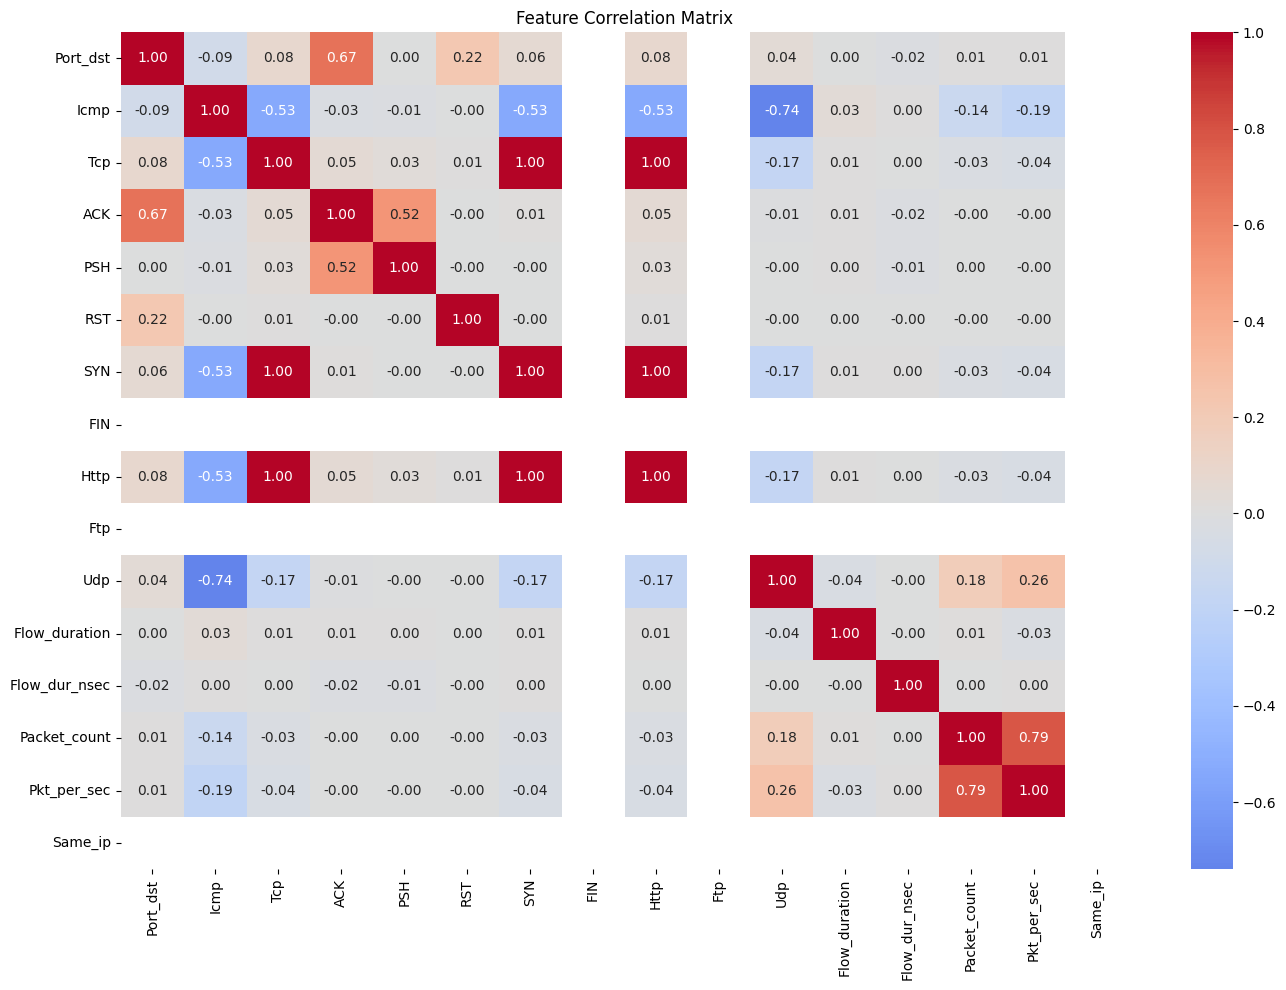

Highly correlated pairs (>0.9):
  Tcp <-> SYN: 0.999
  Tcp <-> Http: 1.000
  SYN <-> Http: 0.999


In [6]:
numeric_cols = RF_FEATURES

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# highly correlated pairs (threshold 0.9)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print('Highly correlated pairs (>0.9):')
for a, b, v in high_corr:
    print(f'  {a} <-> {b}: {v:.3f}')

# Drop redundant features based on correlation

In [11]:
COLS_TO_DROP = ['SYN', 'Http']

FINAL_FEATURES = [f for f in RF_FEATURES if f not in COLS_TO_DROP]
print('Final features:', FINAL_FEATURES)

Final features: ['Port_dst', 'Icmp', 'Tcp', 'ACK', 'PSH', 'RST', 'FIN', 'Ftp', 'Udp', 'Flow_duration', 'Flow_dur_nsec', 'Packet_count', 'Pkt_per_sec', 'Same_ip']


# Label encoding and train-test split

Label distribution:
label
4    396480
5    380310
1    354143
3    323400
2     71100
0      1710
Name: count, dtype: int64


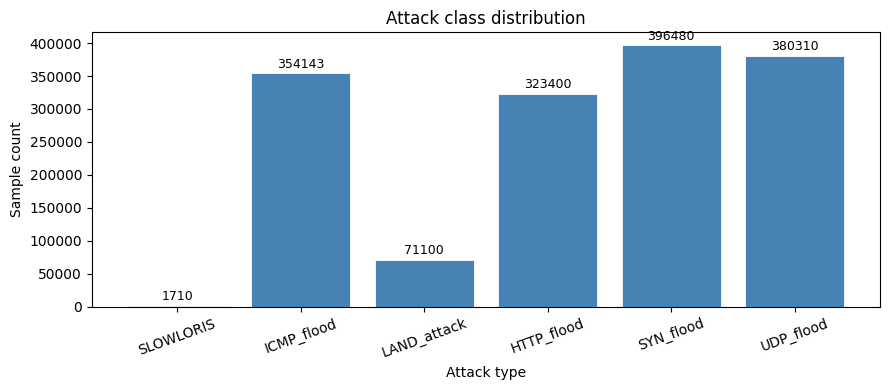

In [29]:
le = LabelEncoder()

# encode attack types to integers matching ATTACK_LABELS
label_map = {v: k for k, v in ATTACK_LABELS.items()}

df['label'] = df['Attack_type'].map(label_map)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

X = df[FINAL_FEATURES].copy()
X['Port_dst'] = X['Port_dst'].apply(filter_port)
y = df['label']

print('Label distribution:')
print(y.value_counts())

# class distribution bar chart
fig, ax = plt.subplots(figsize=(9, 4))
counts = y.value_counts().sort_index()
bars = ax.bar(
    [ATTACK_LABELS[i] for i in counts.index],
    counts.values,
    color='steelblue', edgecolor='white', linewidth=0.6,
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.01,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=9,
    )
ax.set_title('Attack class distribution')
ax.set_xlabel('Attack type')
ax.set_ylabel('Sample count')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# RF Preprocess

In [30]:
X_rf = X.copy()

mm  = MinMaxScaler()
std = StandardScaler()

# only scale cols that are still present after dropping
mm_cols  = [c for c in RF_MINMAX_COLS  if c in X_rf.columns]
std_cols = [c for c in RF_STANDARD_COLS if c in X_rf.columns]

X_rf[mm_cols]  = mm.fit_transform(X_rf[mm_cols])
X_rf[std_cols] = std.fit_transform(X_rf[std_cols])

X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X_rf, y, test_size=0.2, random_state=42, stratify=y
)

# SVM Preprocess

In [31]:
X_svm = X.copy()

svm_std  = StandardScaler()
svm_cols = [c for c in SVM_SCALE_COLS if c in X_svm.columns]
X_svm[svm_cols] = svm_std.fit_transform(X_svm[svm_cols])

X_train_svm, X_test_svm, _, _ = train_test_split(
    X_svm, y, test_size=0.2, random_state=42, stratify=y
)

# Balancing the data with SMOTE

In [32]:
from imblearn.over_sampling import SMOTE

print("Class distribution before SMOTE:")
print(y_train.value_counts().sort_index())

target_counts = {
    0: 20000,  # Slowloris
    2: 100000, # Land attack
}

# SMOTE runs once on raw X_train (before any protocol-specific scaling).
# Scaling is reapplied after because SMOTE generates synthetic samples
# in feature space, scaling before SMOTE is fine too, but doing it
# once here on unscaled X avoids the shape mismatch entirely.
smote = SMOTE(sampling_strategy=target_counts, random_state=42)
X_train_bal, y_train = smote.fit_resample(X_train_rf, y_train)

# RF version: X_train_rf is already MinMax+Std scaled from RF Preprocess cell (cell 14),
# so X_train_bal inherits that scaling. Use directly.
X_train_rf = X_train_bal

# SVM version: re-scale the SMOTE output with SVM's StandardScaler.
# We refit on the balanced data so the scaler reflects the new distribution.
X_train_svm_df  = pd.DataFrame(X_train_bal, columns=FINAL_FEATURES)
svm_std_refit   = StandardScaler()
svm_cols_active = [c for c in SVM_SCALE_COLS if c in X_train_svm_df.columns]
X_train_svm_df[svm_cols_active] = svm_std_refit.fit_transform(
    X_train_svm_df[svm_cols_active]
)
X_train_svm = X_train_svm_df.values

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

Class distribution before SMOTE:
label
0      1368
1    283314
2     56880
3    258720
4    317184
5    304248
Name: count, dtype: int64

Class distribution after SMOTE:
label
0     20000
1    283314
2    100000
3    258720
4    317184
5    304248
Name: count, dtype: int64


# Train RF

In [ ]:
rf = RandomForestClassifier(n_estimators=130, random_state=42, n_jobs=-1) # it was 100 trees before
rf.fit(X_train_rf, y_train)
y_pred_rf = rf.predict(X_test_rf)

print('=' * 10)
print('Random Forest')
print('=' * 10)
print(classification_report(y_test, y_pred_rf,
      target_names=list(ATTACK_LABELS.values())))

Random Forest
              precision    recall  f1-score   support

   SLOWLORIS       0.95      0.97      0.96       342
  ICMP_flood       0.73      0.71      0.72     70829
 LAND_attack       0.79      0.86      0.82     14220
  HTTP_flood       0.92      0.86      0.89     64680
   SYN_flood       0.71      0.78      0.74     79296
   UDP_flood       0.83      0.80      0.81     76062

    accuracy                           0.79    305429
   macro avg       0.82      0.83      0.83    305429
weighted avg       0.79      0.79      0.79    305429



d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


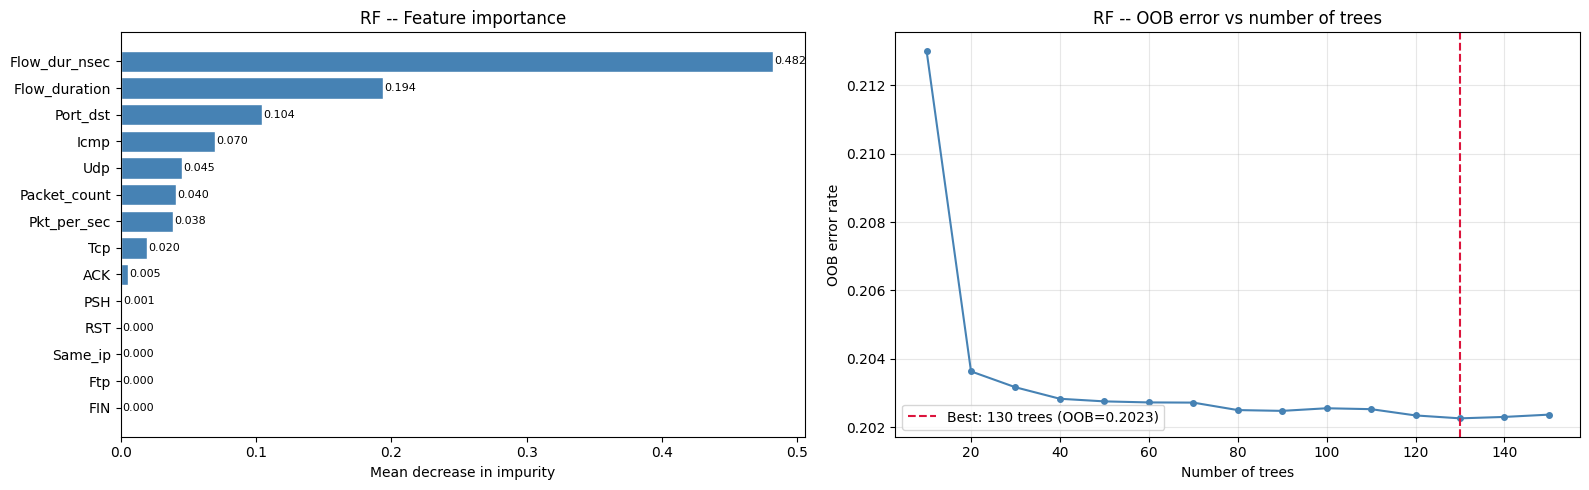

Optimal n_estimators from OOB sweep: 130


In [ ]:
# RF: feature importance + OOB error curve

# --- feature importance ---
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feat_names = [FINAL_FEATURES[i] for i in indices]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(feat_names[::-1], importances[indices][::-1],
             color='steelblue', edgecolor='white')
axes[0].set_title('RF -- Feature importance')
axes[0].set_xlabel('Mean decrease in impurity')
for i, v in enumerate(importances[indices][::-1]):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

# --- OOB error as a proxy for training convergence (n_estimators sweep) ---
# Trains RF with increasing n_estimators and records OOB error at each step.
# This is the RF equivalent of a loss curve.
rf_oob = RandomForestClassifier(
    warm_start=True, oob_score=True, random_state=42, n_jobs=-1
)
oob_errors = []
estimator_range = range(10, 151, 10)
for n in estimator_range:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_train_rf, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

axes[1].plot(list(estimator_range), oob_errors,
             marker='o', markersize=4, color='steelblue', linewidth=1.5)
axes[1].set_title('RF -- OOB error vs number of trees')
axes[1].set_xlabel('Number of trees')
axes[1].set_ylabel('OOB error rate')
axes[1].grid(True, alpha=0.3)

best_n = list(estimator_range)[int(np.argmin(oob_errors))]
axes[1].axvline(best_n, color='crimson', linestyle='--',
                label=f'Best: {best_n} trees (OOB={min(oob_errors):.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Optimal n_estimators from OOB sweep: {best_n}')

# Train SVM

In [40]:
# svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
# svm.fit(X_train_svm, y_train)
# y_pred_svm = svm.predict(X_test_svm)

# print('=' * 10)
# print('SVM')
# print('=' * 10)
# print(classification_report(y_test, y_pred_svm,
#       target_names=list(ATTACK_LABELS.values())))

# SVC(kernel='rbf') is O(n^2) memory and O(n^3) training time.
# With 100k+ rows after SMOTE it runs for hours. it literally ran for +100 minutes and did not finish.
# Nystroem approximates the rbf kernel mapping,
# then SGDClassifier trains a linear SVM on that mapping in O(n) time.
# Accuracy is within 1-2% of full SVC on large datasets. (based on AI)


# # fro memory efficiency, I convert to float32 before feeding into the pipeline.
# X_train_svm = X_train_svm.astype('float32')
# X_test_svm = X_test_svm.astype('float32')

gamma = 1 / X_train_svm.shape[1]

svm_pipe = make_pipeline(
    # StandardScaler(),
    Nystroem(kernel='rbf', gamma=gamma, n_components=220, random_state=42),
    SGDClassifier(loss='hinge', max_iter=1000, tol=1e-3,
                  class_weight='balanced', random_state=42, n_jobs=-1),
)

svm_pipe.fit(X_train_svm, y_train)
y_pred_svm = svm_pipe.predict(X_test_svm)

print('=' * 10)
print('SVM (Nystroem + SGD approximation)')
print('=' * 10)
print(classification_report(y_test, y_pred_svm,
      target_names=list(ATTACK_LABELS.values())))

d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but Nystroem was fitted without feature names
  warnings.warn(


SVM (Nystroem + SGD approximation)
              precision    recall  f1-score   support

   SLOWLORIS       0.03      1.00      0.05       342
  ICMP_flood       0.36      0.81      0.50     70829
 LAND_attack       0.00      0.00      0.00     14220
  HTTP_flood       0.69      0.64      0.67     64680
   SYN_flood       0.00      0.00      0.00     79296
   UDP_flood       0.46      0.46      0.46     76062

    accuracy                           0.44    305429
   macro avg       0.26      0.48      0.28    305429
weighted avg       0.35      0.44      0.37    305429



d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

In [ ]:
# SGDClassifier uses alpha (= 1/C) for regularization.
# Sweep alpha to find the best regularization strength.
# This replaces the C-sweep cross-val that used full SVC (too slow).


alpha_values = [1e-5, 1e-4, 1e-3, 1e-2, 0.1]
cv_means = []
cv_stds  = []

for alpha in alpha_values:
    pipe = make_pipeline(
        # StandardScaler(),
        Nystroem(kernel='rbf', gamma=0.01, n_components=250, random_state=42),
        SGDClassifier(loss='hinge', alpha=alpha, max_iter=1000,
                      class_weight='balanced', random_state=42)
    )
    scores = cross_val_score(pipe, X_train_svm, y_train,
                             cv=3, scoring='accuracy', n_jobs=-1)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([str(a) for a in alpha_values], cv_means,
        marker='o', color='coral', linewidth=1.5, markersize=5,
        label='CV accuracy (mean)')
ax.fill_between(range(len(alpha_values)),
                cv_means - cv_stds,
                cv_means + cv_stds,
                alpha=0.2, color='coral', label='+/- 1 std')
ax.set_title('SVM (Nystroem+SGD) -- 3-fold CV accuracy vs alpha')
ax.set_xlabel('alpha  (regularization strength, lower = less regularized)')
ax.set_ylabel('Accuracy')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

best_alpha = alpha_values[int(np.argmax(cv_means))]
print(f'Best alpha: {best_alpha}  (CV accuracy: {max(cv_means):.4f})')

# Confusion Matrix

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = list(ATTACK_LABELS.values())

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_svm],
    ['Random Forest', 'SVM'],
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax,
    )
    ax.set_title(f'{title} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Per-class F1 score comparison between RF and SVM

In [ ]:
from sklearn.metrics import f1_score

f1_rf  = f1_score(y_test, y_pred_rf,  average=None, labels=list(ATTACK_LABELS.keys()))
f1_svm = f1_score(y_test, y_pred_svm, average=None, labels=list(ATTACK_LABELS.keys()))

x     = np.arange(len(ATTACK_LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_rf  = ax.bar(x - width / 2, f1_rf,  width, label='Random Forest', color='steelblue')
bars_svm = ax.bar(x + width / 2, f1_svm, width, label='SVM',           color='coral')

ax.set_xticks(x)
ax.set_xticklabels(list(ATTACK_LABELS.values()), rotation=15)
ax.set_ylim(0, 1.12)
ax.set_ylabel('F1 score')
ax.set_title('Per-class F1 score -- RF vs SVM')
ax.legend()

for bar in list(bars_rf) + list(bars_svm):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=8,
    )

plt.tight_layout()
plt.show()

# Comparison between RF and SVM results

In [ ]:
metrics = {
    'Accuracy':  [accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_svm)],
    'Precision': [precision_score(y_test, y_pred_rf, average='weighted'),
                  precision_score(y_test, y_pred_svm, average='weighted')],
    'Recall':    [recall_score(y_test, y_pred_rf, average='weighted'),
                  recall_score(y_test, y_pred_svm, average='weighted')],
    'F1':        [f1_score(y_test, y_pred_rf, average='weighted'),
                  f1_score(y_test, y_pred_svm, average='weighted')],
}

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_rf  = ax.bar(x - width / 2, [v[0] for v in metrics.values()],
                  width, label='Random Forest', color='steelblue')
bars_svm = ax.bar(x + width / 2, [v[1] for v in metrics.values()],
                  width, label='SVM', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('RF vs SVM -- Performance Comparison')
ax.legend()

# labels
for bar in bars_rf:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_svm:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Save models

In [ ]:
with open('../ryu-controller/RF.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../ryu-controller/SVM.pkl', 'wb') as f:
    pickle.dump(svm_pipe, f)

print('Models saved.')
print(f'\nRF  accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'SVM accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'\nBetter model: {"RF" if accuracy_score(y_test, y_pred_rf) > accuracy_score(y_test, y_pred_svm) else "SVM"}')

### Saving the models as `onnx` files for compatibility with RYU on python 3.8

In [ ]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

n_features   = len(FINAL_FEATURES)
initial_type = [('float_input', FloatTensorType([None, n_features]))]

# RF
rf_onnx = convert_sklearn(rf, initial_types=initial_type)
with open('../ryu-controller/RF.onnx', 'wb') as f:
    f.write(rf_onnx.SerializeToString())

# SVM pipeline: skl2onnx supports sklearn Pipelines directly
svm_onnx = convert_sklearn(svm_pipe, initial_types=initial_type)
with open('../ryu-controller/SVM.onnx', 'wb') as f:
    f.write(svm_onnx.SerializeToString())

print('RF.onnx and SVM.onnx saved.')